<a href="https://colab.research.google.com/github/Baidunafter/NN/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%963_%D0%A1%D0%B2%D0%B5%D1%80%D1%82%D0%BE%D1%87%D0%BD%D1%8B%D0%B5_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D0%B5_%D1%81%D0%B5%D1%82%D0%B8_(CNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Задание №1. Использование глубокой сверточной нейронной сети для классификации предметов одежды на примере датасета Fashion MNIST**


**В качестве интерфейса для работы с моделями используйте [Streamlit](https://colab.research.google.com/drive/1PUvx9rGgAYSb2dZfGbzjfqRK86CLzsko#scrollTo=kSbmm9EjH5Uz)**

[Техническая документация по датасету](https://www.kaggle.com/datasets/zalando-research/fashionmnist)

## 1.1. Устанавливаем необходимые зависимости

In [12]:
import os
import shutil
import random
import pickle
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import BytesIO
from PIL import Image
import cv2
from imutils import paths
from collections import Counter
from sklearn.datasets import fetch_olivetti_faces
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_absolute_error
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Reshape
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import kagglehub
from google.colab import drive, files

In [ ]:
drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/NN_3'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

## 1.2. Разделяем данные на обучающую и тестовую выборку

In [13]:
(trainX, trainy), (testX, testy) = fashion_mnist.load_data()

print('Train: X = ', trainX.shape)
print('Test: X = ', testX.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train: X =  (60000, 28, 28)
Test: X =  (10000, 28, 28)


## 1.3. Визуализируем часть данных из датасета

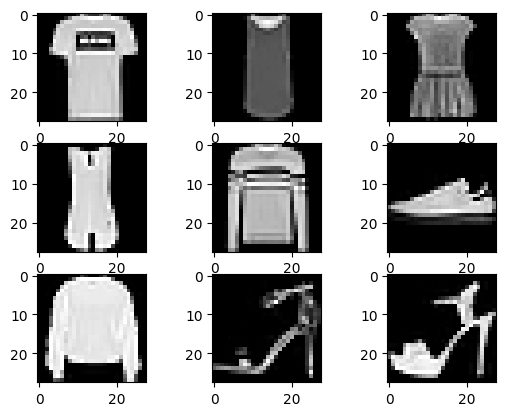

In [14]:
for i in range(1, 10):
    plt.subplot(3, 3, i)
    plt.imshow(trainX[i], cmap=plt.get_cmap('gray'))

plt.show()

## 1.4. Создаём архитектуру нейронной сети и компилируем модель

In [15]:
trainX = trainX.astype('float32') / 255.0
testX = testX.astype('float32') / 255.0
trainX = trainX.reshape(trainX.shape[0], 28, 28, 1)
testX = testX.reshape(testX.shape[0], 28, 28, 1)

model_cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model_cnn.compile(optimizer=Adam(),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

model_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 1.5. Обучаем модель

In [16]:
history = model_cnn.fit(trainX, trainy,
                        validation_split=0.2,
                        epochs=10,
                        batch_size=128,
                        verbose=1)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 28s 67ms/step - accuracy: 0.7498 - loss: 0.6979 - val_accuracy: 0.8438 - val_loss: 0.4267
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 25s 68ms/step - accuracy: 0.8410 - loss: 0.4458 - val_accuracy: 0.8728 - val_loss: 0.3461
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 66ms/step - accuracy: 0.8625 - loss: 0.3814 - val_accuracy: 0.8814 - val_loss: 0.3198
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 25s 66ms/step - accuracy: 0.8746 - loss: 0.3485 - val_accuracy: 0.8853 - val_loss: 0.3060
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 63ms/step - accuracy: 0.8840 - loss: 0.3244 - val_accuracy: 0.8876 - val_loss: 0.2958
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 63ms/step - accuracy: 0.8897 - loss: 0.3068 - val_accuracy: 0.8949 - val_loss: 0.2830
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 42s 65ms/step - accuracy: 0.8963 - loss: 0.2884 - val_accuracy: 0.8992 - val_loss: 0.2771
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 24s 63ms/step - accuracy: 0.9013 - loss: 0.2740 - 

## 1.6. Анализируем обученную модель. Строим график (графики) обучения

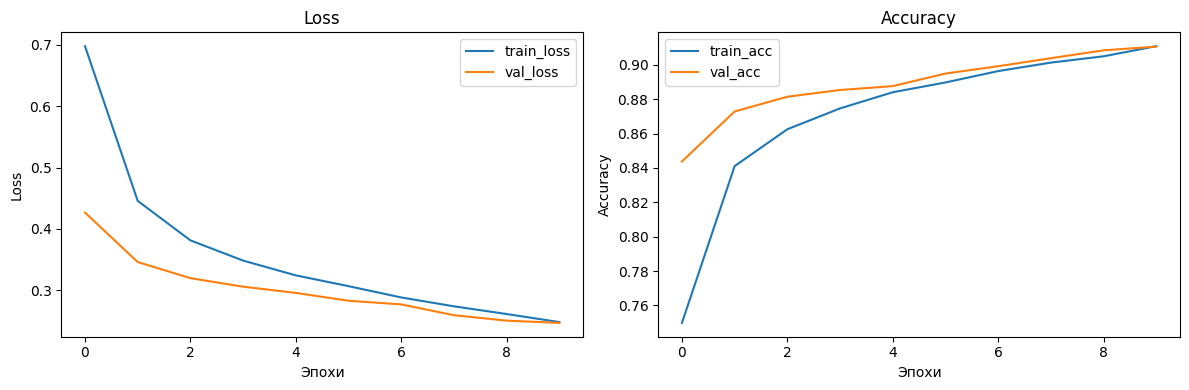

In [17]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Эпохи')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## 1.7. Загружаем свои изображения. С помощью функции predict() получаем предсказание нейронной сети



> Требуется получить предсказания минимум по 5 изображениям, каждое из которых относится к разному классу. Не забудьте добавить метки к каждому классу (для этого можно просто создать список строк, каждая из которых будет соответствовать классу с определенным индексом см. [тех.док.](https://www.kaggle.com/datasets/zalando-research/fashionmnist)). Процент уверенности нейронной сети в своём предсказании выводить обязательно.




Изображение 1: T-shirt/top (вероятность: 0.903)
Топ-3 предсказания:
  T-shirt/top: 0.903
  Shirt: 0.097
  Pullover: 0.000

Изображение 2: Trouser (вероятность: 1.000)
Топ-3 предсказания:
  Trouser: 1.000
  Dress: 0.000
  Coat: 0.000

Изображение 3: Pullover (вероятность: 0.513)
Топ-3 предсказания:
  Pullover: 0.513
  Shirt: 0.368
  T-shirt/top: 0.041

Изображение 4: Dress (вероятность: 0.999)
Топ-3 предсказания:
  Dress: 0.999
  Trouser: 0.001
  Bag: 0.000

Изображение 5: Coat (вероятность: 0.483)
Топ-3 предсказания:
  Coat: 0.483
  Bag: 0.185
  Dress: 0.133


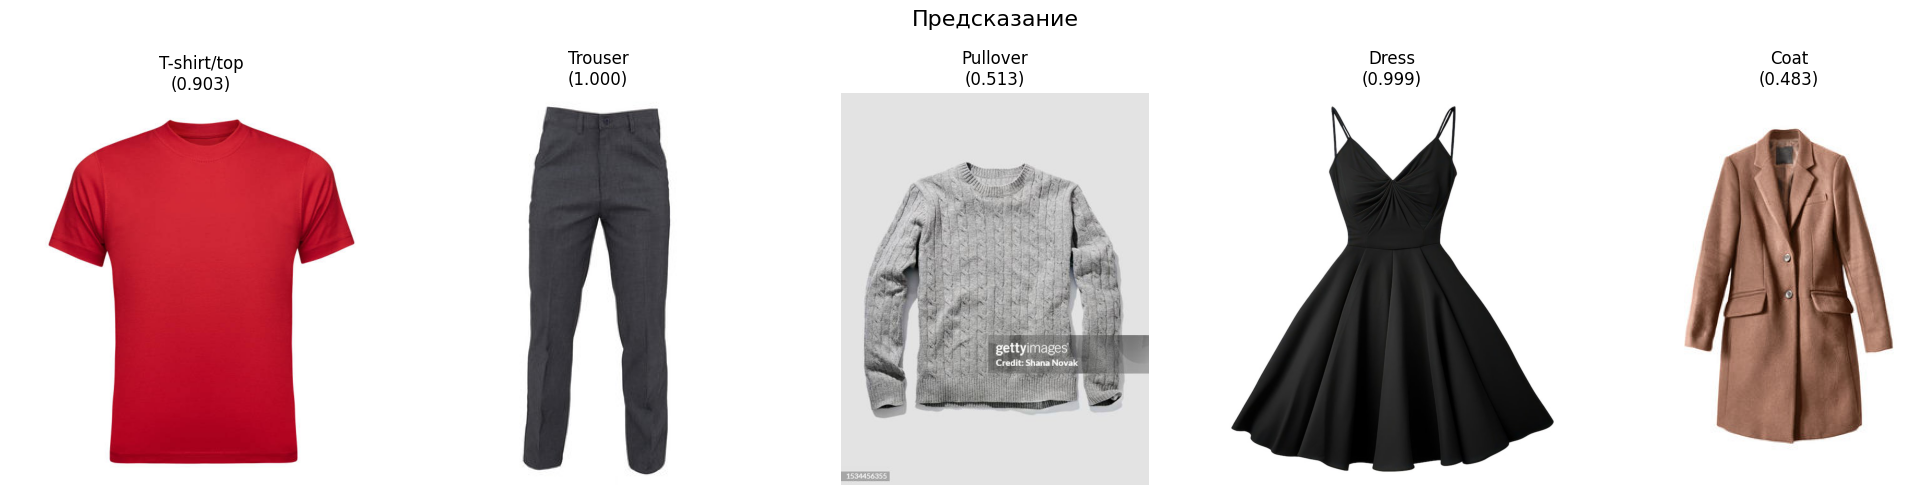

In [18]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

def load_and_preprocess_image_from_url(url):
    response = requests.get(url, timeout=10)
    original_img = Image.open(BytesIO(response.content))
    img_for_model = original_img.copy()

    img_for_model = img_for_model.convert('L')

    img_array = np.array(img_for_model)
    img_array = 255 - img_array

    img_for_model = Image.fromarray(img_array)
    img_for_model.thumbnail((28, 28), Image.Resampling.LANCZOS)

    new_img = Image.new('L', (28, 28), 0)

    width, height = img_for_model.size
    left = (28 - width) // 2
    top = (28 - height) // 2

    new_img.paste(img_for_model, (left, top))

    img_array = np.array(new_img) / 255.0
    img_array = img_array.reshape(1, 28, 28, 1)

    return img_array, original_img

image_urls = [
    "https://media.istockphoto.com/id/1354031012/photo/red-t-shirt-mockup-men-as-design-template-tee-shirt-blank-isolated-on-white-front-view.jpg?s=612x612&w=0&k=20&c=_5QLLkUa0-ZzSK1rp6Ie-ZRBPOEku4as4ZMrZg-y2GI=",
    "https://t3.ftcdn.net/jpg/00/61/87/62/360_F_61876261_FUoySFWEGESVVmMuqJidqri9r5hA0ln5.jpg",
    "https://media.gettyimages.com/id/1534456355/photo/cashmere-sweater.jpg?s=612x612&w=gi&k=20&c=2k858ATAsJZDHyq8cxUXN3lU_76Xc1WOqQnT5jFpCSA=",
    "https://img.freepik.com/premium-photo/png-fashion-dress-gown-celebration_53876-726088.jpg?semt=ais_hybrid&w=740&q=80",
    "https://t4.ftcdn.net/jpg/01/61/88/17/360_F_161881774_DmKODbtiEUVG06qJOTMbn5V9fjUmdk1h.jpg"
]

fig, axes = plt.subplots(1, len(image_urls), figsize=(20, 5))
fig.suptitle('Предсказание', fontsize=16)

for i, url in enumerate(image_urls):
    try:
        img_array, original_img = load_and_preprocess_image_from_url(url)

        pred = model_cnn.predict(img_array, verbose=0)[0]
        class_idx = np.argmax(pred)
        confidence = pred[class_idx]

        axes[i].imshow(original_img)
        axes[i].set_title(f'{class_names[class_idx]}\n({confidence:.3f})', fontsize=12)
        axes[i].axis('off')

        print(f"\nИзображение {i+1}: {class_names[class_idx]} (вероятность: {confidence:.3f})")
        print(f"Топ-3 предсказания:")
        top3 = np.argsort(pred)[-3:][::-1]
        for idx in top3:
            print(f"  {class_names[idx]}: {pred[idx]:.3f}")

    except Exception as e:
        print(f"Ошибка: {e}")
        axes[i].axis('off')

plt.tight_layout()
plt.show()

# **Задание №2. Использование глубокой сверточной нейронной сети для классификации изображений по своему датасету**


## 2.1.  Используя датасет, собранный для предыдущей работы, разработайте и обучите **свою** модель глубокой  **сверточной** нейронной сети для классификации изображений







In [19]:
dataset_path = kagglehub.dataset_download("mohamedaziz15/cars-brands-in-egypt")

print("Path to dataset files:", dataset_path)

Using Colab cache for faster access to the 'cars-brands-in-egypt' dataset.
Path to dataset files: /kaggle/input/cars-brands-in-egypt


In [72]:
brands = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
print("Все бренды:", brands)

valid_brands = []
for brand in brands:
    brand_dir = os.path.join(dataset_path, brand)
    images = list(paths.list_images(brand_dir))
    count = len(images)
    print(f"{brand}: {count} изображений")
    if count >= 1000:
        valid_brands.append((brand, count))

valid_brands.sort(key=lambda x: x[1], reverse=True)
selected_brands = [b[0] for b in valid_brands[:3]]
print(f"\nВыбраны бренды: {selected_brands}")

counts_dict = dict(valid_brands)
min_count = min(counts_dict[brand] for brand in selected_brands)

data = []
labels = []
target_size = (64, 64)

print(f"\nЗагрузка {min_count} изображений для каждого бренда...")
for brand in selected_brands:
    brand_dir = os.path.join(dataset_path, brand)
    image_paths = list(paths.list_images(brand_dir))
    random.shuffle(image_paths)
    count = 0
    for img_path in image_paths:
        if count >= min_count:
            break
        image = cv2.imread(img_path)
        if image is None:
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, target_size)
        image = image.astype("float32") / 255.0
        data.append(image)
        labels.append(brand)
        count += 1

print(f"\nВсего загружено изображений: {len(data)}")
print("Распределение по классам:")
print(Counter(labels))

Все бренды: ['nissan', 'Ford', 'Mercedes-Benz', 'Byd', 'volkswagen', 'lada', 'Honda', 'kia', 'Hundai', 'Toyota', 'Suzuki', 'Skoda', 'Mitsubishi', 'Chevrolet', 'Renault', 'BMW']
nissan: 514 изображений
Ford: 932 изображений
Mercedes-Benz: 823 изображений
Byd: 252 изображений
volkswagen: 425 изображений
lada: 206 изображений
Honda: 898 изображений
kia: 691 изображений
Hundai: 1176 изображений
Toyota: 1232 изображений
Suzuki: 1448 изображений
Skoda: 487 изображений
Mitsubishi: 661 изображений
Chevrolet: 808 изображений
Renault: 922 изображений
BMW: 994 изображений

Выбраны бренды: ['Suzuki', 'Toyota', 'Hundai']

Загрузка 1176 изображений для каждого бренда...

Всего загружено изображений: 3528
Распределение по классам:
Counter({'Suzuki': 1176, 'Toyota': 1176, 'Hundai': 1176})


In [73]:
X = np.array(data, dtype=np.float32)
y = np.array(labels)

print(f"Форма данных X: {X.shape}")

Форма данных X: (3528, 64, 64, 3)


In [74]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded, num_classes=len(selected_brands))
class_names = selected_brands
num_classes = len(class_names)

print(f"Закодированные метки:")
for i, brand in enumerate(class_names):
    print(f"  {brand}: {i}")

print(f"Форма y_categorical: {y_categorical.shape}")

Закодированные метки:
  Suzuki: 0
  Toyota: 1
  Hundai: 2
Форма y_categorical: (3528, 3)


In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

print("\nРаспределение классов в train:")
train_labels_idx = np.argmax(y_train, axis=1)
train_counts = Counter([int(x) for x in train_labels_idx])
for brand_idx, brand in enumerate(class_names):
    print(f"  {brand}: {train_counts[brand_idx]} изображений")

print("\nРаспределение классов в test:")
test_labels_idx = np.argmax(y_test, axis=1)
test_counts = Counter([int(x) for x in test_labels_idx])
for brand_idx, brand in enumerate(class_names):
    print(f"  {brand}: {test_counts[brand_idx]} изображений")

Обучающая выборка: (2822, 64, 64, 3)
Тестовая выборка: (706, 64, 64, 3)

Распределение классов в train:
  Suzuki: 941 изображений
  Toyota: 941 изображений
  Hundai: 940 изображений

Распределение классов в test:
  Suzuki: 235 изображений
  Toyota: 235 изображений
  Hundai: 236 изображений


In [76]:
X_test_cars = X_test.copy()
y_test_cars = y_test.copy()

In [77]:
INIT_LR = 0.0001
EPOCHS = 30
BATCH_SIZE = 32

print(f"Количество классов: {num_classes}")
print(f"Классы: {class_names}")

callbacks = [
    ModelCheckpoint("best_model.h5", monitor='val_accuracy', mode='max', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1)
]

Количество классов: 3
Классы: ['Suzuki', 'Toyota', 'Hundai']


In [25]:
def create_my_cnn(input_shape=(64, 64, 3), num_classes=num_classes):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        Conv2D(32, (3,3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(0.25),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(0.25),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(0.25),

        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

model_my_cnn = create_my_cnn()
model_my_cnn.compile(optimizer=Adam(learning_rate=0.0001),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])
model_my_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,417,699 (9.22 MB)

 Trainable params: 2,417,699 (9.22 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy',
                             mode='max', save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10,
                           restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=5, min_lr=1e-7, verbose=1)

In [27]:
history_my = model_my_cnn.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=32,
    epochs=30,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

Epoch 1/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - accuracy: 0.3444 - loss: 1.0886
Epoch 1: val_accuracy improved from None to 0.57790, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 56s 604ms/step - accuracy: 0.3767 - loss: 1.0653 - val_accuracy: 0.5779 - val_loss: 0.9405 - learning_rate: 1.0000e-04
Epoch 2/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 576ms/step - accuracy: 0.5377 - loss: 0.8977
Epoch 2: val_accuracy improved from 0.57790 to 0.60340, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 57s 636ms/step - accuracy: 0.5482 - loss: 0.8580 - val_accuracy: 0.6034 - val_loss: 0.7593 - learning_rate: 1.0000e-04
Epoch 3/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 0.6008 - loss: 0.7675
Epoch 3: val_accuracy improved from 0.60340 to 0.64731, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 80s 619ms/step - accuracy: 0.6045 - loss: 0.7598 - val_accuracy: 0.6473 - val_loss: 0.7039 - learning_rate: 1.0000e-04
Epoch 4/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.6136 - loss: 0.7300
Epoch 4: val_accuracy did not improve from 0.64731
89/89 ━━━━━━━━━━━━━━━━━━━━ 80s 593ms/step - accuracy: 0.6113 - loss: 0.7248 - val_accuracy: 0.6445 - val_loss: 0.6824 - learning_rate: 1.0000e-04
Epoch 5/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - accuracy: 0.6179 - loss: 0.6919
Epoch 5: val_accuracy improved from 0.64731 to 0.67705, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 82s 599ms/step - accuracy: 0.6297 - loss: 0.6788 - val_accuracy: 0.6771 - val_loss: 0.6520 - learning_rate: 1.0000e-04
Epoch 6/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.6474 - loss: 0.6541
Epoch 6: val_accuracy improved from 0.67705 to 0.71530, saving model to best_model.h5


...


Epoch 20: finished saving model to best_model.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 83s 624ms/step - accuracy: 0.8373 - loss: 0.3690 - val_accuracy: 0.8456 - val_loss: 0.3977 - learning_rate: 1.0000e-04
Epoch 21/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.8632 - loss: 0.3344
Epoch 21: val_accuracy did not improve from 0.84561
89/89 ━━━━━━━━━━━━━━━━━━━━ 81s 606ms/step - accuracy: 0.8533 - loss: 0.3455 - val_accuracy: 0.8456 - val_loss: 0.3921 - learning_rate: 1.0000e-04
Epoch 22/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.8483 - loss: 0.3305
Epoch 22: val_accuracy did not improve from 0.84561
89/89 ━━━━━━━━━━━━━━━━━━━━ 82s 612ms/step - accuracy: 0.8519 - loss: 0.3356 - val_accuracy: 0.8329 - val_loss: 0.3982 - learning_rate: 1.0000e-04
Epoch 23/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - accuracy: 0.8622 - loss: 0.3247
Epoch 23: val_accuracy did not improve from 0.84561
89/89 ━━━━━━━━━━━━━━━━━━━━ 55s 622ms/step - accuracy: 0.8597 - loss: 0.3196 - val_accuracy: 0.8


Epoch 24: finished saving model to best_model.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 57s 645ms/step - accuracy: 0.8724 - loss: 0.3057 - val_accuracy: 0.8499 - val_loss: 0.3746 - learning_rate: 1.0000e-04
Epoch 25/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 0.8820 - loss: 0.3060
Epoch 25: val_accuracy improved from 0.84986 to 0.85411, saving model to best_model.h5



Epoch 25: finished saving model to best_model.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 54s 612ms/step - accuracy: 0.8753 - loss: 0.3024 - val_accuracy: 0.8541 - val_loss: 0.3828 - learning_rate: 1.0000e-04
Epoch 26/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - accuracy: 0.8874 - loss: 0.2810
Epoch 26: val_accuracy improved from 0.85411 to 0.85694, saving model to best_model.h5



Epoch 26: finished saving model to best_model.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 53s 596ms/step - accuracy: 0.8909 - loss: 0.2795 - val_accuracy: 0.8569 - val_loss: 0.3785 - learning_rate: 1.0000e-04
Epoch 27/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 0.8795 - loss: 0.2747
Epoch 27: val_accuracy did not improve from 0.85694
89/89 ━━━━━━━━━━━━━━━━━━━━ 82s 593ms/step - accuracy: 0.8816 - loss: 0.2782 - val_accuracy: 0.8555 - val_loss: 0.3801 - learning_rate: 1.0000e-04
Epoch 28/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - accuracy: 0.9021 - loss: 0.2472
Epoch 28: val_accuracy improved from 0.85694 to 0.87394, saving model to best_model.h5



Epoch 28: finished saving model to best_model.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 82s 599ms/step - accuracy: 0.9029 - loss: 0.2493 - val_accuracy: 0.8739 - val_loss: 0.3396 - learning_rate: 1.0000e-04
Epoch 29/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.9113 - loss: 0.2306
Epoch 29: val_accuracy did not improve from 0.87394
89/89 ━━━━━━━━━━━━━━━━━━━━ 54s 603ms/step - accuracy: 0.9068 - loss: 0.2393 - val_accuracy: 0.8683 - val_loss: 0.3609 - learning_rate: 1.0000e-04
Epoch 30/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.8924 - loss: 0.2628
Epoch 30: val_accuracy did not improve from 0.87394
89/89 ━━━━━━━━━━━━━━━━━━━━ 84s 629ms/step - accuracy: 0.8962 - loss: 0.2523 - val_accuracy: 0.8612 - val_loss: 0.3443 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 28.


In [29]:
model_save_path = f'{save_dir}/my_cnn_best_model.h5'
if os.path.exists(model_save_path):
    os.remove(model_save_path)
shutil.copy('best_model.h5', model_save_path)
print(f"Модель сохранена на Google Диск: {model_save_path}")

Модель сохранена на Google Диск: /content/drive/MyDrive/NN_3/my_cnn_best_model.h5


In [30]:
def load_my_cnn_model():
    return load_model(f'{save_dir}/my_cnn_best_model.h5')

## 2.2.   Ознакомьтесь с архитектурами сверточных нейронных сетей:

![Текст ссылки](https://velog.velcdn.com/images%2Fimfromk%2Fpost%2Fc04b189d-29cb-405d-93d0-b98dec818517%2Fimage.png)

На основе рассмотренных архитектур, реализуйте (частично повторяя основные паттерны проектирования) и обучите модель сверточной нейронной сети. Укажите архитектуру, которой Вы "вдохновились"

In [31]:
def create_vgg_like_model(input_shape=(64, 64, 3), num_classes=3):
    model = Sequential([
        Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2), strides=(2, 2)),

        Conv2D(128, (3, 3), activation='relu', padding='same'),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2), strides=(2, 2)),

        Conv2D(256, (3, 3), activation='relu', padding='same'),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2), strides=(2, 2)),

        Conv2D(512, (3, 3), activation='relu', padding='same'),
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2), strides=(2, 2)),

        Conv2D(512, (3, 3), activation='relu', padding='same'),
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2), strides=(2, 2)),

        Flatten(),
        Dense(4096, activation='relu'),
        Dropout(0.5),
        Dense(4096, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

vgg_like_model = create_vgg_like_model(input_shape=(64,64,3), num_classes=num_classes)
vgg_like_model.compile(optimizer=Adam(learning_rate=0.0001),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])
vgg_like_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 4096)           │     8,392,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │        12,291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,900,995 (152.21 MB)

 Trainable params: 39,900,995 (152.21 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
checkpoint_vgg = ModelCheckpoint('best_model_vgg.h5', monitor='val_accuracy',
                                 mode='max', save_best_only=True, verbose=1)
early_stop_vgg = EarlyStopping(monitor='val_loss', patience=10,
                               restore_best_weights=True, verbose=1)
reduce_lr_vgg = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                  patience=5, min_lr=1e-7, verbose=1)

history_vgg = vgg_like_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=32,
    epochs=30,
    callbacks=[checkpoint_vgg, early_stop_vgg, reduce_lr_vgg],
    verbose=1
)

Epoch 1/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3475 - loss: 1.0808
Epoch 1: val_accuracy improved from None to 0.60765, saving model to best_model_vgg.h5



Epoch 1: finished saving model to best_model_vgg.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 432s 5s/step - accuracy: 0.4199 - loss: 1.0071 - val_accuracy: 0.6076 - val_loss: 0.7210 - learning_rate: 1.0000e-04
Epoch 2/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5868 - loss: 0.7329
Epoch 2: val_accuracy improved from 0.60765 to 0.62465, saving model to best_model_vgg.h5



Epoch 2: finished saving model to best_model_vgg.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 465s 5s/step - accuracy: 0.5960 - loss: 0.7111 - val_accuracy: 0.6246 - val_loss: 0.6281 - learning_rate: 1.0000e-04
Epoch 3/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6285 - loss: 0.6173
Epoch 3: val_accuracy did not improve from 0.62465
89/89 ━━━━━━━━━━━━━━━━━━━━ 456s 5s/step - accuracy: 0.6219 - loss: 0.6405 - val_accuracy: 0.6246 - val_loss: 0.6184 - learning_rate: 1.0000e-04
Epoch 4/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6282 - loss: 0.5957
Epoch 4: val_accuracy improved from 0.62465 to 0.63031, saving model to best_model_vgg.h5



Epoch 4: finished saving model to best_model_vgg.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 460s 5s/step - accuracy: 0.6446 - loss: 0.5895 - val_accuracy: 0.6303 - val_loss: 0.5870 - learning_rate: 1.0000e-04
Epoch 5/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6237 - loss: 0.5921
Epoch 5: val_accuracy improved from 0.63031 to 0.68130, saving model to best_model_vgg.h5



Epoch 5: finished saving model to best_model_vgg.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 439s 5s/step - accuracy: 0.6389 - loss: 0.5732 - val_accuracy: 0.6813 - val_loss: 0.5629 - learning_rate: 1.0000e-04
Epoch 6/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6629 - loss: 0.5400
Epoch 6: val_accuracy did not improve from 0.68130
89/89 ━━━━━━━━━━━━━━━━━━━━ 459s 5s/step - accuracy: 0.6722 - loss: 0.5310 - val_accuracy: 0.6813 - val_loss: 0.5925 - learning_rate: 1.0000e-04
Epoch 7/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6968 - loss: 0.5218
Epoch 7: val_accuracy improved from 0.68130 to 0.72096, saving model to best_model_vgg.h5


...


Epoch 14: finished saving model to best_model_vgg.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 452s 5s/step - accuracy: 0.9266 - loss: 0.1838 - val_accuracy: 0.8895 - val_loss: 0.3354 - learning_rate: 1.0000e-04
Epoch 15/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9407 - loss: 0.1477
Epoch 15: val_accuracy did not improve from 0.88952
89/89 ━━━━━━━━━━━━━━━━━━━━ 435s 5s/step - accuracy: 0.9369 - loss: 0.1553 - val_accuracy: 0.8683 - val_loss: 0.3590 - learning_rate: 1.0000e-04
Epoch 16/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9527 - loss: 0.1131
Epoch 16: val_accuracy improved from 0.88952 to 0.89235, saving model to best_model_vgg.h5



Epoch 16: finished saving model to best_model_vgg.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 466s 5s/step - accuracy: 0.9571 - loss: 0.1095 - val_accuracy: 0.8924 - val_loss: 0.3314 - learning_rate: 1.0000e-04
Epoch 17/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9779 - loss: 0.0625
Epoch 17: val_accuracy improved from 0.89235 to 0.91218, saving model to best_model_vgg.h5



Epoch 17: finished saving model to best_model_vgg.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 448s 5s/step - accuracy: 0.9688 - loss: 0.0878 - val_accuracy: 0.9122 - val_loss: 0.3290 - learning_rate: 1.0000e-04
Epoch 18/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9782 - loss: 0.0563
Epoch 18: val_accuracy did not improve from 0.91218
89/89 ━━━━━━━━━━━━━━━━━━━━ 447s 5s/step - accuracy: 0.9763 - loss: 0.0678 - val_accuracy: 0.8909 - val_loss: 0.4130 - learning_rate: 1.0000e-04
Epoch 19/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9724 - loss: 0.0717
Epoch 19: val_accuracy did not improve from 0.91218
89/89 ━━━━━━━━━━━━━━━━━━━━ 506s 5s/step - accuracy: 0.9621 - loss: 0.1104 - val_accuracy: 0.9008 - val_loss: 0.2884 - learning_rate: 1.0000e-04
Epoch 20/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9753 - loss: 0.0713
Epoch 20: val_accuracy did not improve from 0.91218
89/89 ━━━━━━━━━━━━━━━━━━━━ 456s 5s/step - accuracy: 0.9748 - loss: 0.0717 - val_accuracy: 0.9023 - val_los


Epoch 23: finished saving model to best_model_vgg.h5
89/89 ━━━━━━━━━━━━━━━━━━━━ 435s 5s/step - accuracy: 0.9791 - loss: 0.0627 - val_accuracy: 0.9150 - val_loss: 0.2967 - learning_rate: 1.0000e-04
Epoch 24/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9884 - loss: 0.0360
Epoch 24: val_accuracy did not improve from 0.91501

Epoch 24: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
89/89 ━━━━━━━━━━━━━━━━━━━━ 464s 5s/step - accuracy: 0.9848 - loss: 0.0467 - val_accuracy: 0.8853 - val_loss: 0.3604 - learning_rate: 1.0000e-04
Epoch 25/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9881 - loss: 0.0376
Epoch 25: val_accuracy did not improve from 0.91501
89/89 ━━━━━━━━━━━━━━━━━━━━ 422s 5s/step - accuracy: 0.9926 - loss: 0.0237 - val_accuracy: 0.8994 - val_loss: 0.4442 - learning_rate: 5.0000e-05
Epoch 26/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 1.0000 - loss: 0.0019
Epoch 26: val_accuracy did not improve from 0.91501
89/89 ━━━━━━━━━━━━━━━━━━━━ 4


Epoch 29: finished saving model to best_model_vgg.h5

Epoch 29: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
89/89 ━━━━━━━━━━━━━━━━━━━━ 432s 5s/step - accuracy: 1.0000 - loss: 2.5683e-04 - val_accuracy: 0.9178 - val_loss: 0.5493 - learning_rate: 5.0000e-05
Epoch 29: early stopping
Restoring model weights from the end of the best epoch: 19.


## 2.3. Сохраните полученные модели

In [33]:
vgg_save_path = f'{save_dir}/vgg_like_best_model.h5'
if os.path.exists(vgg_save_path):
    os.remove(vgg_save_path)
shutil.copy('best_model_vgg.h5', vgg_save_path)
print(f"Модель VGG-like сохранена: {vgg_save_path}")

Модель VGG-like сохранена: /content/drive/MyDrive/NN_3/vgg_like_best_model.h5


In [34]:
def load_vgg_like_model():
    return load_model(f'{save_dir}/vgg_like_best_model.h5')

## 2.4. Загрузите обученную модель из прошлой практической работы


In [35]:
def load_dense_model():
    return load_model('/content/drive/MyDrive/NN_2/final_car_model_cnn.h5')


## 2.5. Сравните между собой точной всех трёх моделей, подавая на вход одинаковые изображения (15 разных изображений). Сравните предсказания каждой из моделей и сделайте выводы

Точность своей CNN: 0.9333
Точность VGG-like: 1.0000
Точность модели из прошлой работы: 0.6667


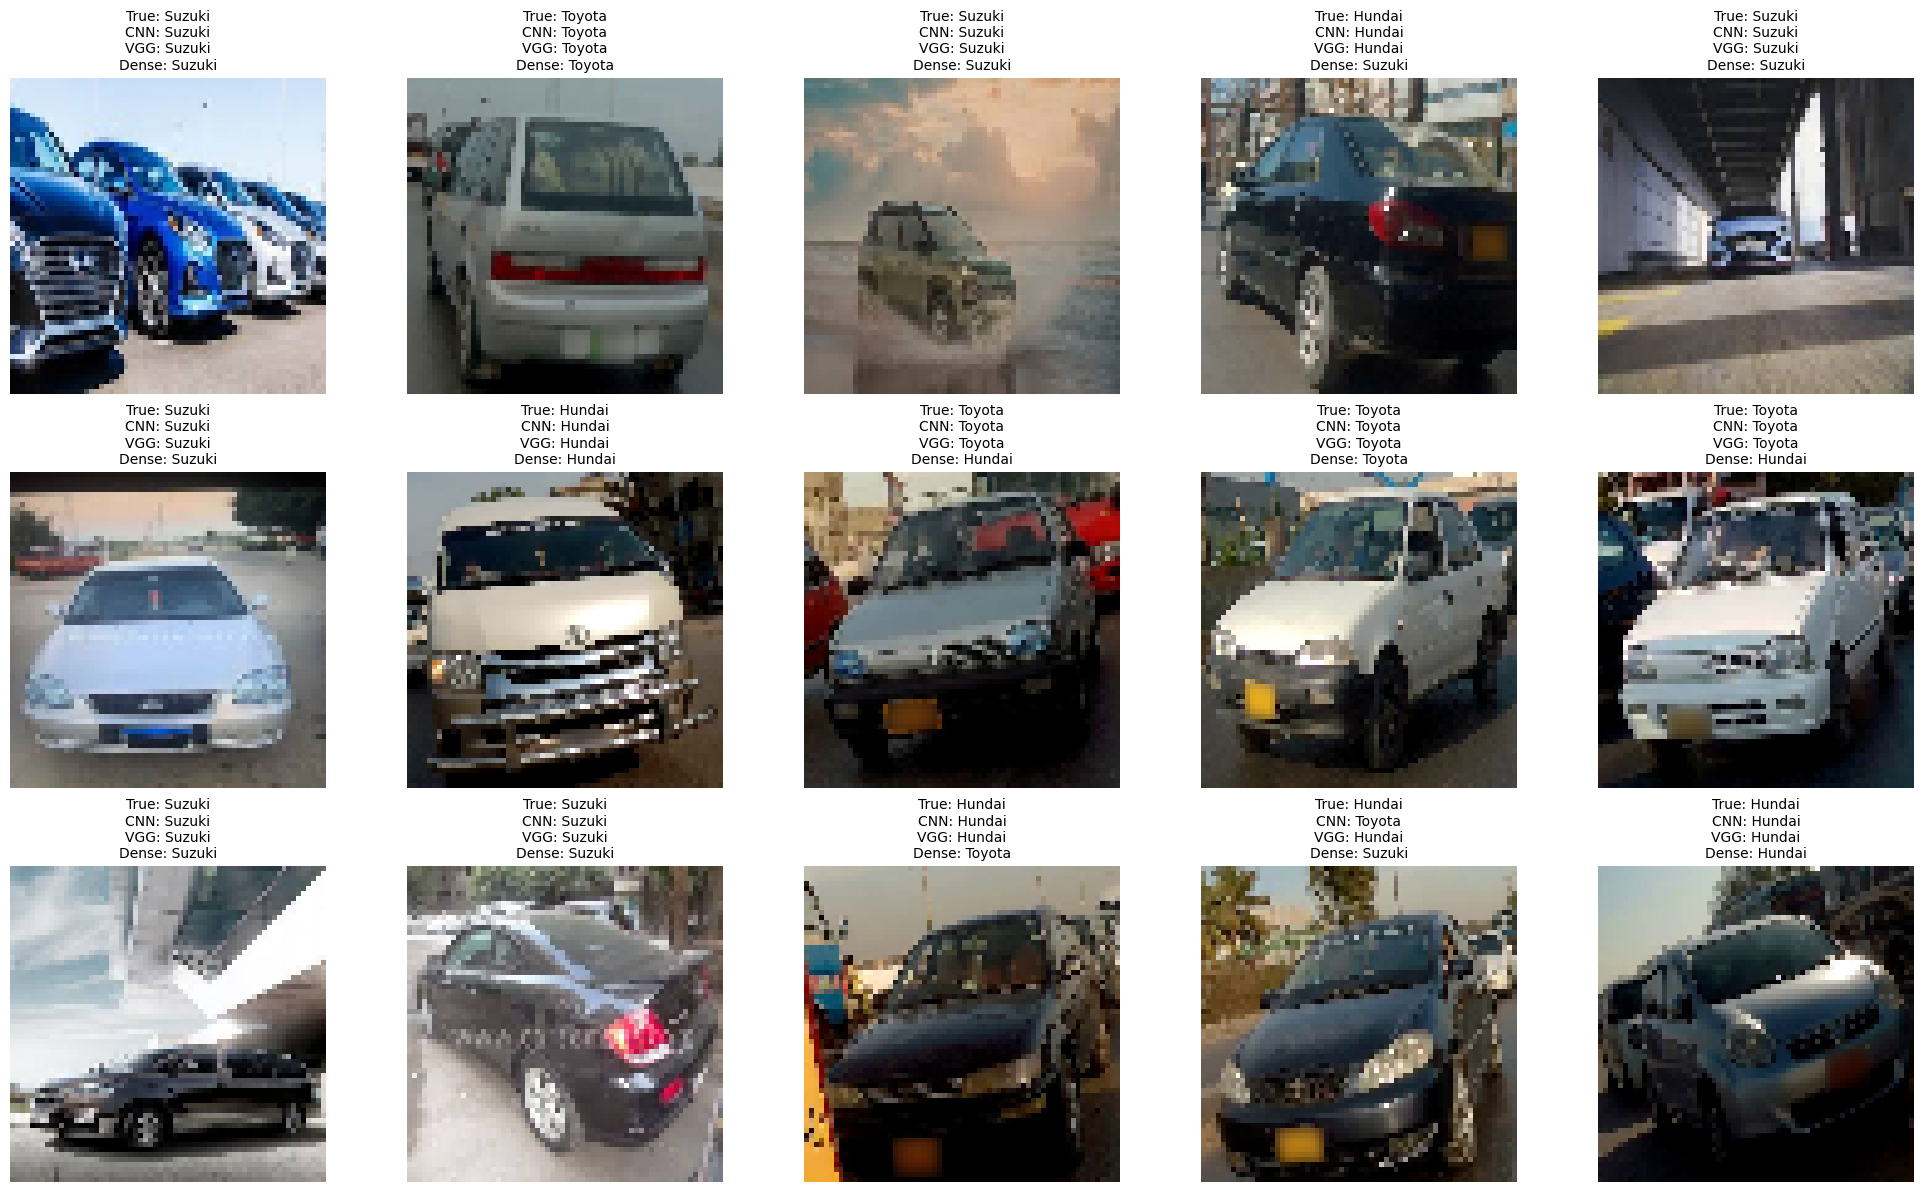

In [78]:
model1 = load_my_cnn_model()
model2 = load_vgg_like_model()
model3 = load_dense_model()

num_samples = 15
indices = np.random.choice(len(X_test_cars), num_samples, replace=False)
X_sample = X_test_cars[indices]
y_true = np.argmax(y_test_cars[indices], axis=1)

pred1 = np.argmax(model1.predict(X_sample, verbose=0), axis=1)
pred2 = np.argmax(model2.predict(X_sample, verbose=0), axis=1)

X_sample_flat = X_sample.reshape(num_samples, -1)
pred3 = np.argmax(model3.predict(X_sample_flat, verbose=0), axis=1)

class_names = ['Suzuki', 'Toyota', 'Hundai']

acc1 = accuracy_score(y_true, pred1)
acc2 = accuracy_score(y_true, pred2)
acc3 = accuracy_score(y_true, pred3)
print(f"Точность своей CNN: {acc1:.4f}")
print(f"Точность VGG-like: {acc2:.4f}")
print(f"Точность модели из прошлой работы: {acc3:.4f}")

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i in range(num_samples):
    axes[i].imshow(X_sample[i])
    true_label = class_names[y_true[i]]
    pred1_label = class_names[pred1[i]]
    pred2_label = class_names[pred2[i]]
    pred3_label = class_names[pred3[i]]

    title = f"True: {true_label}\nCNN: {pred1_label}\nVGG: {pred2_label}\nDense: {pred3_label}"
    axes[i].set_title(title, fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# **Задание №3. Использование глубокой сверточной нейронной сети для восстановления изображения**

## 3.1. Работа с данными

Будем работать с набором данным `fetch_olivetti_faces` из `sklearn`.

### 3.1.1. Переведите векторы в настоящие изображения из двух размерностей

In [95]:
data, _ = fetch_olivetti_faces(return_X_y=True)
train_face, test_face = train_test_split(data, test_size=0.2, random_state=4)

train_face = train_face.reshape((train_face.shape[0], 64, 64))
test_face = test_face.reshape((test_face.shape[0], 64, 64))

In [96]:
train.shape

(320, 64, 64)

Сейчас изображение - это вектор, имеющий размерность 4096.

In [97]:
# Ваш код здесь

train = train.reshape((train.shape[0], 64, 64))
test = test.reshape((test.shape[0], 64, 64))

test.shape

(80, 64, 64)

### 3.1.2. Отрисуйте несколько примеров

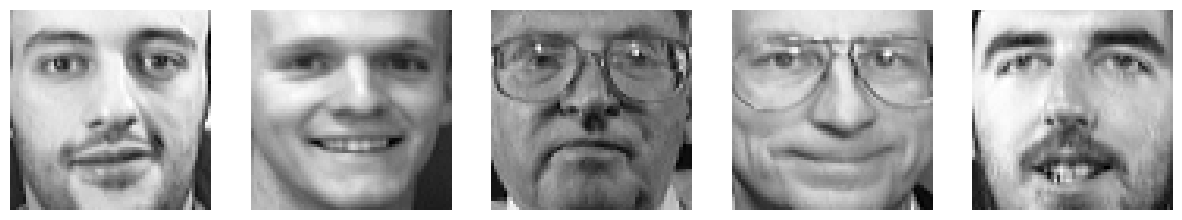

In [98]:
fig, ax = plt.subplots(1, 5, figsize=(15, 10))

for i in range(5):
    ax[i].imshow(train[i], cmap='gray')
    ax[i].axis('off')

Поделим данные на X и y, где X - это верхняя часть лица человека, на этом модель будет обучаться, а y - это нижняя часть лица человека - её будем предсказывать.

In [99]:
n_pixels = train_face.shape[1]

X_train_face = train_face[:, :(n_pixels + 1) // 2, :]
y_train_face = train_face[:, n_pixels // 2:, :]

X_test_face = test_face[:, :(n_pixels + 1) // 2, :]
y_test_face = test_face[:, n_pixels // 2:, :]

In [100]:
X_train.shape

(320, 32, 64)

Вот один пример обучающей пары.

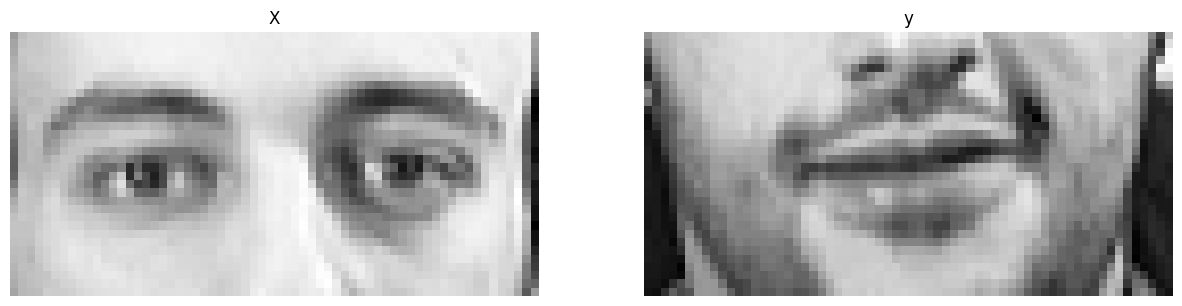

In [101]:
idx = 0

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(X_train[idx], cmap='gray')
ax[0].set_title('X')
ax[1].imshow(y_train[idx], cmap='gray')
ax[1].set_title('y')
ax[0].axis('off')
ax[1].axis('off')

plt.show()

### 3.1.3. Измените размерность y
Остается только изменить размерность y, т.к. сейчас $y$ - картинка 32x64, а выход нейронной сети у нас будет одномерный и равный 32 * 64 = 2048.

In [102]:
y_train_n = y_train_face.reshape(y_train_face.shape[0], 32 * 64)
y_test_n = y_test_face.reshape(y_test_face.shape[0], 32 * 64)

## 3.2. Создайте архитектуру для этой задачи

In [103]:
def build_face_completion_model():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32, 64, 1)),
        MaxPooling2D((2,2)),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        Flatten(),
        Dense(1024, activation='relu'),
        Dense(2048, activation='linear')
    ])
    return model

face_model = build_face_completion_model()
face_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_42 (Conv2D)              │ (None, 32, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 16, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 16, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 8, 16, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 8, 16, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1024)           │    16,778,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 2048)           │     2,099,200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,970,112 (72.37 MB)

 Trainable params: 18,970,112 (72.37 MB)

 Non-trainable params: 0 (0.00 B)

## 3.3. Скомпилируйте сеть

Подберите нужную функцию потерь и метрику. Оптимизатор можете использовать 'adam'

In [104]:
face_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

## 3.4. Обучите нейросеть

Выберите нужное количество эпох.


In [105]:
X_train_reshaped = X_train_face.reshape(-1, 32, 64, 1)
X_test_reshaped = X_test_face.reshape(-1, 32, 64, 1)

history_face = face_model.fit(
    X_train_reshaped, y_train_n,
    validation_data=(X_test_reshaped, y_test_n),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 413ms/step - loss: 0.0930 - mae: 0.2370 - val_loss: 0.0302 - val_mae: 0.1381
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 326ms/step - loss: 0.0258 - mae: 0.1268 - val_loss: 0.0227 - val_mae: 0.1219
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 319ms/step - loss: 0.0205 - mae: 0.1133 - val_loss: 0.0192 - val_mae: 0.1088
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 334ms/step - loss: 0.0191 - mae: 0.1090 - val_loss: 0.0215 - val_mae: 0.1138
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 319ms/step - loss: 0.0196 - mae: 0.1111 - val_loss: 0.0185 - val_mae: 0.1062
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 409ms/step - loss: 0.0197 - mae: 0.1110 - val_loss: 0.0181 - val_mae: 0.1069
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 317ms/step - loss: 0.0180 - mae: 0.1056 - val_loss: 0.0177 - val_mae: 0.1055
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 317ms/step - loss: 0.0182 - mae: 0.1065 - val_loss: 0.0176 - val_mae: 0.1053
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 414ms/step - lo

## 3.5. Сделайте предсказания на тестовых данных

In [106]:
preds = face_model.predict(X_test_reshaped)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


## 3.6. Посчитайте метрику качества на тестовых данных

In [107]:
mae = mean_absolute_error(preds.reshape(-1, 2048), y_test_n)
print(f"MAE на тесте: {mae:.4f}")

MAE на тесте: 0.0737


## 3.7. Преобразуйте предсказанные векторы в двумерное изображение (поменяйте их размерность)

In [108]:
pred_test = preds.reshape(-1, 32, 64)

Отрисуйте все предсказания.

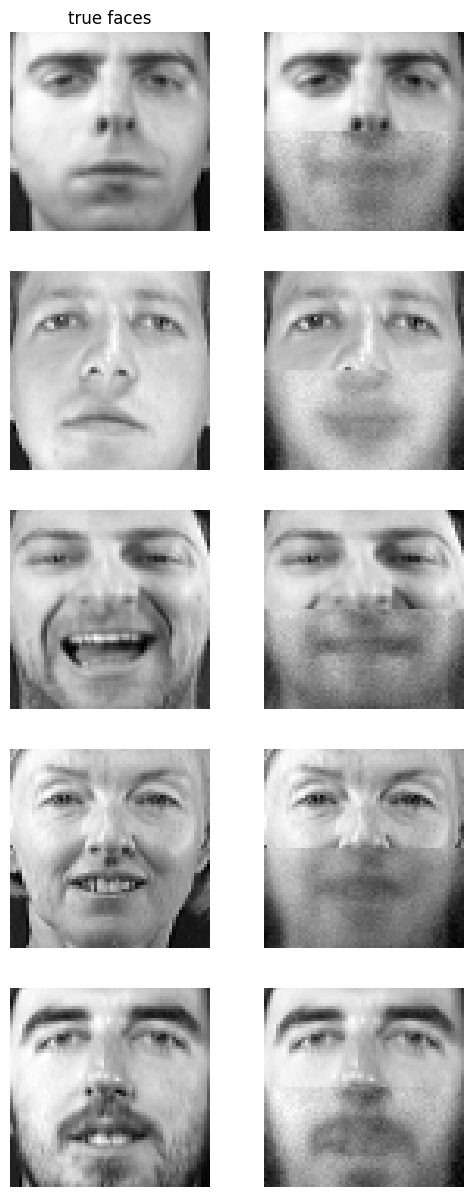

In [112]:
pred_test = preds.reshape(-1, 32, 64)

n_faces = 5
n_cols = 2
image_shape = (64, 64)
plt.figure(figsize=(3 * n_cols, 3 * n_faces))

for i in range(5):
    true_face = np.vstack((X_test_face[i], y_test_face[i]))
    if i:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1)
    else:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1, title="true faces")

    sub.axis("off")
    sub.imshow(
        true_face.reshape(image_shape), cmap=plt.cm.gray, interpolation="nearest"
    )

    completed_face = np.vstack((X_test[i], pred_test[i]))

    if i:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 2)

    else:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 2)

    sub.axis("off")
    sub.imshow(
        completed_face.reshape(image_shape),
        cmap=plt.cm.gray,
        interpolation="nearest",
    )

## 3.8. Предскажите нижнюю половину лица по верхей из загруженной Вами фото (лицо на фото может быть чье угодно)

Saving images.jpg to images (7).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


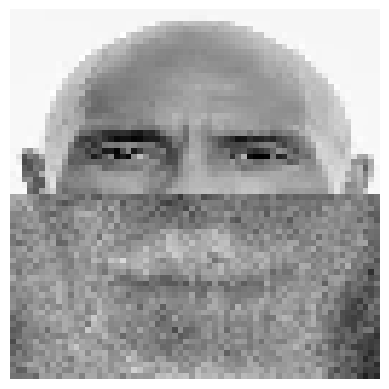

In [113]:
uploaded = files.upload()

for fn in uploaded.keys():
    img = cv2.imread(fn, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (64, 64))
    img_inv = 255 - img
    upper_half = img_inv[:32, :] / 255.0
    upper_half_input = upper_half.reshape(1, 32, 64, 1)
    pred_lower = face_model.predict(upper_half_input)[0].reshape(32, 64)

    completed_norm = np.vstack((upper_half, pred_lower))
    completed = 1.0 - completed_norm
    completed = np.clip(completed, 0, 1)

    plt.imshow(completed, cmap='gray')
    plt.axis('off')
    plt.show()